# A/B Testing Analysis: Evaluating Landing Page Performance

### Objective
The objective of this project is to determine whether the new landing page leads to a higher conversion rate than the existing landing page using A/B testing and statistical hypothesis testing.

## Project Workflow

1. Importing Libraries 
2. Data Loading
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Hypothesis Formulation
7. Statistical Hypothesis Testing
8. Confidence Interval Analysis
9. Experiment Summary
10. Business Recommendation
11. Final Conclusion

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

## Data Loading

In [3]:
df = pd.read_csv("ab_data.csv")

## Data Understanding

In [4]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


(294478, 5)

In [5]:
df.nunique()

user_id         290584
timestamp       294478
group                2
landing_page         2
converted            2
dtype: int64

In [6]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [7]:
df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

In [8]:
df['converted'].value_counts()

converted
0    259241
1     35237
Name: count, dtype: int64

In [9]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


## Data Cleaning
Before performing the A/B test, the dataset was cleaned by removing mismatched records and duplicate users to ensure accurate and unbiased analysis.

In [10]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [11]:
mismatch = ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) | ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))
mismatch.sum()

3893

In [12]:
df2 = df[~mismatch].copy()

In [37]:
print(df.shape)
print(df2.shape)

(294478, 5)
(290584, 5)


In [14]:
pd.crosstab(df2['group'], df2['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [15]:
df2['user_id'].duplicated().sum()
df2[df2['user_id'].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [16]:
df2.drop_duplicates(subset='user_id', inplace=True)

In [17]:
df2['user_id'].duplicated().sum()

0

In [18]:
df2['landing_page'].value_counts()
df2['converted'].value_counts()
df2['group'].value_counts()

group
treatment    145310
control      145274
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

In [19]:
overall_conversion = df2['converted'].mean()
print(f'Overall Conversion: {overall_conversion:.2%}')

Overall Conversion: 11.96%


In [20]:
conversion_rate = df2.groupby('group')['converted'].mean()
conversion_rate

group
control      0.120386
treatment    0.118808
Name: converted, dtype: float64

### Observation
The overall conversion rate of the cleaned dataset is **11.96%**, indicating that approximately 12 out of every 100 users completed the desired action.

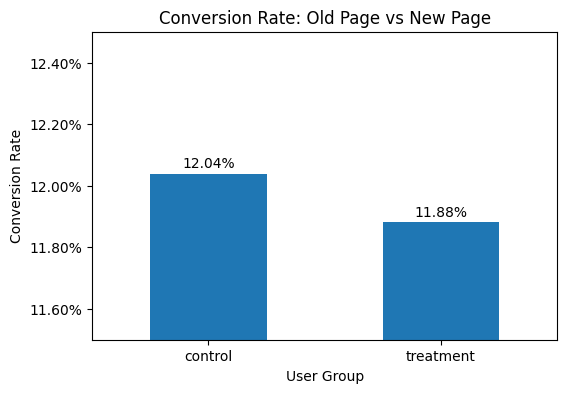

In [24]:
ax = conversion_rate.plot(kind='bar', figsize=(6,4))

plt.title('Conversion Rate: Old Page vs New Page')
plt.xlabel('User Group')
plt.ylabel('Conversion Rate')

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=0)
plt.ylim(0.115, 0.125)

for i, value in enumerate(conversion_rate):
    ax.text(i, value + 0.0002, f'{value:.2%}', ha='center')

plt.savefig('Images/conversion_rate.png', dpi=300, bbox_inches='tight')
plt.show()
#Business Insight: Based on the observed Conversion Rates, the old landing page appears to perform slightly better than the new landing page. However, the difference is very small,
# so statiscal testing is needed before making any business decision.

## Hypothesis Formulation

### A/B Testing Analysis

### Business Objective

To determine whether the new landing page leads to a higher conversion rate than the old landing page.

### Hypothesis Testing

#### Null Hypothesis (H₀)

The new landing page does **not** improve the conversion rate compared to the old landing page. Any observed difference in conversion rates is due to random chance.

#### Alternative Hypothesis (H₁)

The new landing page has a **higher** conversion rate than the old landing page.

#### Data Required for A/B Testing

To perform the A/B test, we first calculate the number of users and the number of conversions in both the control and treatment groups. These values will be used to compare the conversion rates and perform the statistical hypothesis test.

In [26]:
n_old = df2[df2['group'] == 'control'].shape[0]
n_new = df2[df2['group'] == 'treatment'].shape[0]

In [27]:
convert_old = df2.query("group == 'control'")['converted'].sum()
convert_new = df2.query("group == 'treatment'")['converted'].sum()

In [28]:
print("Control Group Users:", n_old)
print("Treatment Group Users:", n_new)
print("Control Group Conversion:", convert_old)
print("Treatment Group Conversion:", convert_new)

Control Group Users: 145274
Treatment Group Users: 145310
Control Group Conversion: 17489
Treatment Group Conversion: 17264


## Statistical Testing

To determine whether the new landing page performs better than the old landing page, we will perform a **two-proportion z-test**.

This test compares the conversion rates of the control and treatment groups and helps us determine whether the observed difference is statistically significant or simply due to random chance.

- **Significance Level (α):** 0.05
- If the **p-value < 0.05**, we reject the null hypothesis.
- If the **p-value ≥ 0.05**, we fail to reject the null hypothesis.

In [29]:
from statsmodels.stats.proportion import proportions_ztest

In [30]:
success = [convert_old, convert_new]
sample_size = [n_old, n_new]

In [31]:
z_stats, p_value = proportions_ztest(count=success, nobs=sample_size, alternative='smaller')
print('Z-statistic:', z_stats)
print('P-value:', p_value)

Z-statistic: 1.3109241984234394
P-value: 0.9050583127590245


## Interpretation of Results

The p-value obtained from the two-proportion z-test is **0.9051**, which is greater than the significance level of **0.05**.

Therefore, we **fail to reject the null hypothesis**.

This indicates that there is **not enough statistical evidence** to conclude that the new landing page has a higher conversion rate than the old landing page. The observed difference in conversion rates is likely due to random chance rather than the effect of the new landing page.

## Confidence Interval

A confidence interval provides a range of plausible values for the true difference in conversion rates between the control and treatment groups.

If the confidence interval includes **0**, it suggests that there is no statistically significant difference between the two groups.

In [32]:
from statsmodels.stats.proportion import confint_proportions_2indep

In [33]:
ci_low, ci_high = confint_proportions_2indep(count1=convert_new, nobs1=n_new, count2=convert_old, nobs2=n_old, method='wald')

In [34]:
print('95% Confidence Interval:')
print(f'Lower Bound: {ci_low:.5f}')
print(f'Higher Bound: {ci_high:.5f}')

95% Confidence Interval:
Lower Bound: -0.00394
Higher Bound: 0.00078


## Confidence Interval Interpretation

The 95% confidence interval for the difference in conversion rates is **(-0.00394, 0.00078)**.

Since the confidence interval includes **0**, there is no statistically significant difference between the conversion rates of the old and new landing pages.

This result supports the conclusion from the hypothesis test that there is insufficient evidence to conclude that the new landing page performs better than the old landing page.

## Experiment Summary

The table below summarizes the key metrics used to compare the performance of the control and treatment groups during the A/B test.

In [36]:
summary = pd.DataFrame({
    'Metric': ['Users', 'Conversions', 'Conversion Rate'],
    'Control': [
        n_old,
        convert_old,
        f'{convert_old / n_old:.2%}'
    ],
    'Treatment': [
        n_new,
        convert_new,
        f'{convert_new / n_new:.2%}'
    ]
})

summary

,Metric,Control,Treatment
0,Users,145274,145310
1,Conversions,17489,17264
2,Conversion Rate,12.04%,11.88%


## Business Recommendation

Based on the A/B testing analysis, the new landing page did not show a statistically significant improvement in conversion rate compared to the old landing page.

Therefore, there is insufficient evidence to recommend replacing the old landing page with the new one. The company may continue using the existing landing page or conduct further experiments with different design changes to improve conversion rates.

## Final Conclusion

This project analyzed an A/B test to determine whether a new landing page improved the conversion rate compared to the existing landing page.

After cleaning the dataset by removing mismatched records and duplicate users, the conversion rates of the control and treatment groups were compared.

The control group had a slightly higher conversion rate (12.04%) than the treatment group (11.88%). However, the two-proportion z-test produced a **p-value of 0.9051**, which is greater than the significance level of **0.05**. Additionally, the 95% confidence interval included **0**, indicating that the observed difference in conversion rates is not statistically significant.

Therefore, we fail to reject the null hypothesis and conclude that there is insufficient statistical evidence to support that the new landing page improves the conversion rate.

**Recommendation:** Based on the current experiment, the company should continue using the existing landing page or conduct further A/B tests with new design variations before implementing any changes.